# Визуализация эффективного пространства гиперкубических слоёв

Эксперимент исследует **эффективное пространство** квантованных гиперкубических
линейных слоёв: сколько уникальных паттернов весов реально формируется из латентного
3D-представления через обучаемую матрицу проекции и как это соотносится с теоретическим
пределом.

Цели:
1. Обучить небольшую `HypercubeGPT` на TinyShakespeare.
2. Для выбранных слоёв воспроизвести forward-квантование и подсчитать уникальные паттерны.
3. Оценить геометрический предел: сколько паттернов вообще достижимо из 3D.
4. Визуализировать латентное пространство и покрытие паттернов.

> Зависимости: `torch`, `numpy`, `matplotlib`. При необходимости: `pip install torch numpy matplotlib`

In [5]:
import os, sys, urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Чтобы импортировать `src` из каталога notebooks/
sys.path.append(os.path.abspath('..'))

from src.models.transformers import HypercubeGPT
from src.layers.hypercube_linear_layers import BinaryHypercubeLinear, TernaryHypercubeLinear, TwoBitHypercubeLinear

%matplotlib inline

## 1. Подготовка данных (TinyShakespeare)

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
block_size = 128
batch_size = 64

data_path = os.path.abspath(os.path.join('..', 'input.txt'))
if not os.path.exists(data_path):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, data_path)

with open(data_path, 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

print(f'Устройство: {device} | vocab_size: {vocab_size}')

Устройство: cuda | vocab_size: 65


## 2. Обучение небольшой модели

Используем тернарный гиперкубический слой (`group_size=5`, `latent_dim=3`).
Обучение короткое — лишь чтобы веса «ожили» и проявили паттерны.

In [14]:
LayerClass = TernaryHypercubeLinear
group_size = 5
latent_dim = 3

model = HypercubeGPT(
    vocab_size=vocab_size,
    block_size=block_size,
    embed_dim=128,
    heads=4,
    depth=4,
    linear_cls=LayerClass,
    group_size=group_size,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
max_iters = 2500

model.train()
for it in range(max_iters):
    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if (it + 1) % 100 == 0:
        print(f'Шаг {it+1:4d} | loss: {loss.item():.4f}')

print('Обучение завершено.')

Шаг  100 | loss: 2.5381
Шаг  200 | loss: 2.4336
Шаг  300 | loss: 2.3718
Шаг  400 | loss: 2.2625
Шаг  500 | loss: 2.1773
Шаг  600 | loss: 2.1121
Шаг  700 | loss: 2.0856
Шаг  800 | loss: 1.9976
Шаг  900 | loss: 1.8929
Шаг 1000 | loss: 1.8804
Шаг 1100 | loss: 1.8706
Шаг 1200 | loss: 1.8582
Шаг 1300 | loss: 1.7852
Шаг 1400 | loss: 1.7946
Шаг 1500 | loss: 1.7424
Шаг 1600 | loss: 1.7355
Шаг 1700 | loss: 1.7574
Шаг 1800 | loss: 1.7582
Шаг 1900 | loss: 1.7164
Шаг 2000 | loss: 1.6710
Шаг 2100 | loss: 1.7104
Шаг 2200 | loss: 1.6847
Шаг 2300 | loss: 1.7334
Шаг 2400 | loss: 1.6309
Шаг 2500 | loss: 1.6659
Обучение завершено.


## 3. Анализ паттернов

Воспроизводим квантование forward-прохода и считаем уникальные паттерны по группам.
Число уровней квантования определяется автоматически (2 для бинарного, 3 для тернарного,
4 для 2-бит), поэтому функции работают с любым типом гиперкубического слоя.

> Примечание: в реальном слое атрибут называется `weight_latent` (а не `weight_3d`),
> а нормировка в `forward` идёт по строке по всем группам — это учтено в `reproduce_layer_patterns`.

In [15]:
def get_levels(layer, proj_matrix, group_size, n_samples=200000):
    """Определяет множество уровней квантования, зондируя случайные точки."""
    rnd = torch.randn(n_samples, 1, 3, device=proj_matrix.device)
    space = torch.matmul(rnd, proj_matrix).view(-1, group_size)
    centered = space - space.mean(dim=-1, keepdim=True)
    scale = centered.abs().mean() + 1e-5
    q = layer.quantize(centered / scale)
    return torch.unique(q)


def reproduce_layer_patterns(layer):
    """Точно воспроизводит квантование forward-прохода слоя; возвращает паттерны по группам."""
    weight_latent = layer.weight_latent.detach()
    proj_matrix = layer.proj_matrix.detach()
    group_size = proj_matrix.size(1)

    W_continuous = torch.matmul(weight_latent, proj_matrix)          # [out, groups, group_size]
    W_continuous = W_continuous.view(layer.out_features, -1)         # [out, pad_features]
    W_centered = W_continuous - W_continuous.mean(dim=-1, keepdim=True)
    scale = W_centered.abs().mean() + 1e-5
    W_quantized = layer.quantize(W_centered / scale)                 # [out, pad_features]
    flat_patterns = W_quantized.view(-1, group_size)                 # [out*groups, group_size]
    return flat_patterns, group_size


def analyze_combinations(layer, layer_name='Layer'):
    flat_patterns, group_size = reproduce_layer_patterns(layer)
    flat = flat_patterns.cpu().numpy().astype(int)

    levels = get_levels(layer, layer.proj_matrix.detach(), group_size)
    n_levels = int(levels.numel())
    max_possible = n_levels ** group_size

    unique_patterns, counts = np.unique(flat, axis=0, return_counts=True)
    coverage = len(unique_patterns) / max_possible * 100

    print(f'📊 Анализ слоя: {layer_name} (group_size: {group_size}, уровней: {n_levels})')
    print(f'Всего групп весов: {flat.shape[0]}')
    print(f'Использовано уникальных паттернов: {len(unique_patterns)} из {max_possible} '
          f'({coverage:.2f}%)')
    print('Топ-3 самых частых паттерна:')
    order = np.argsort(-counts)
    for i in range(min(3, len(unique_patterns))):
        idx = order[i]
        print(f'  {unique_patterns[idx].tolist()} -> {counts[idx]} раз')
    print('-' * 50)
    return {
        'patterns': unique_patterns, 'counts': counts,
        'n_used': len(unique_patterns), 'max_possible': max_possible,
        'group_size': group_size, 'n_levels': n_levels,
    }


def check_theoretical_limit(layer, n_points=1000000):
    proj_matrix = layer.proj_matrix.detach()
    group_size = proj_matrix.size(1)
    levels = get_levels(layer, proj_matrix, group_size)
    n_levels = int(levels.numel())
    max_possible = n_levels ** group_size

    rnd = torch.randn(n_points, 1, 3, device=proj_matrix.device)
    space = torch.matmul(rnd, proj_matrix).view(-1, group_size)
    centered = space - space.mean(dim=-1, keepdim=True)
    scale = centered.abs().mean() + 1e-5
    q = layer.quantize(centered / scale)
    flat = q.cpu().numpy().astype(int)
    unique = np.unique(flat, axis=0)

    print(f'📐 Геометрический предел 3D -> {group_size}D (уровней: {n_levels}):')
    print(f'Случайные точки покрывают: {len(unique)} из {max_possible} паттернов '
          f'({len(unique)/max_possible*100:.2f}%)')
    print('=' * 50)
    return {
        'n_reachable': len(unique), 'max_possible': max_possible,
        'group_size': group_size, 'n_levels': n_levels,
    }

In [16]:
check_theoretical_limit(model.blocks[0].attn.q_proj)
res_q = analyze_combinations(model.blocks[0].attn.q_proj, 'Блок 0 — Q_proj')
res_lm = analyze_combinations(model.lm_head, 'Выходной слой (lm_head)')

📐 Геометрический предел 3D -> 5D (уровней: 3):
Случайные точки покрывают: 113 из 243 паттернов (46.50%)
📊 Анализ слоя: Блок 0 — Q_proj (group_size: 5, уровней: 3)
Всего групп весов: 3328
Использовано уникальных паттернов: 123 из 243 (50.62%)
Топ-3 самых частых паттерна:
  [0, 0, 0, 0, 0] -> 171 раз
  [1, -1, 1, -1, -1] -> 93 раз
  [-1, 1, -1, 1, 0] -> 91 раз
--------------------------------------------------
📊 Анализ слоя: Выходной слой (lm_head) (group_size: 5, уровней: 3)
Всего групп весов: 1690
Использовано уникальных паттернов: 103 из 243 (42.39%)
Топ-3 самых частых паттерна:
  [0, 0, 0, 0, 0] -> 310 раз
  [1, 0, 1, -1, -1] -> 59 раз
  [-1, -1, -1, 0, 0] -> 57 раз
--------------------------------------------------


## 4. Визуализация эффективного пространства

- 3D-скаттер латентных координат, окрашенный по id паттерна.
- Топ частот паттернов.
- Сравнение покрытия: теоретический максимум vs геометрический предел vs фактически.

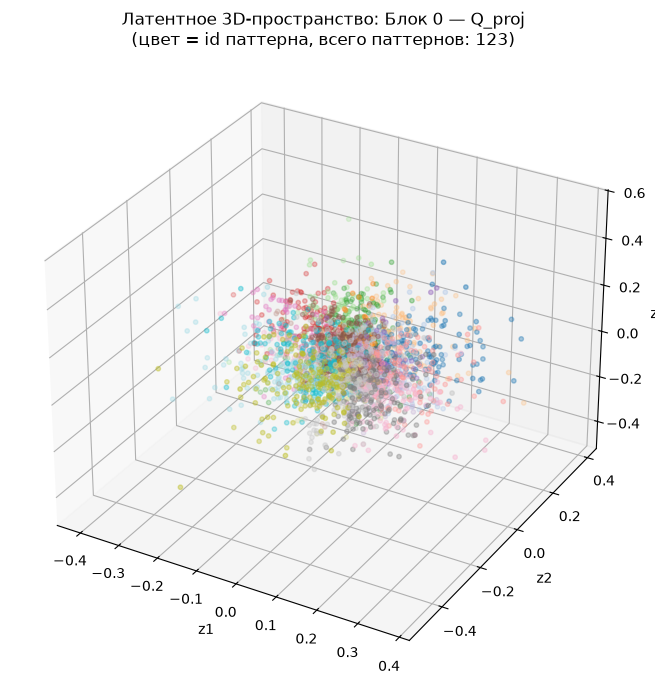

In [17]:
def plot_latent_space(layer, layer_name, max_points=3000):
    weight_latent = layer.weight_latent.detach()
    flat_patterns, _ = reproduce_layer_patterns(layer)
    flat = flat_patterns.cpu().numpy().astype(int)
    _, inv = np.unique(flat, axis=0, return_inverse=True)

    pts = weight_latent.view(-1, 3).cpu().numpy()
    if len(pts) > max_points:
        idx = np.random.choice(len(pts), max_points, replace=False)
        pts = pts[idx]
        inv = inv[idx]

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=inv, cmap='tab20', s=10, alpha=0.7)
    n_patterns = int(inv.max() + 1)
    ax.set_title(f'Латентное 3D-пространство: {layer_name}\n(цвет = id паттерна, всего паттернов: {n_patterns})')
    ax.set_xlabel('z1'); ax.set_ylabel('z2'); ax.set_zlabel('z3')
    plt.tight_layout(); plt.show()

plot_latent_space(model.blocks[0].attn.q_proj, 'Блок 0 — Q_proj')

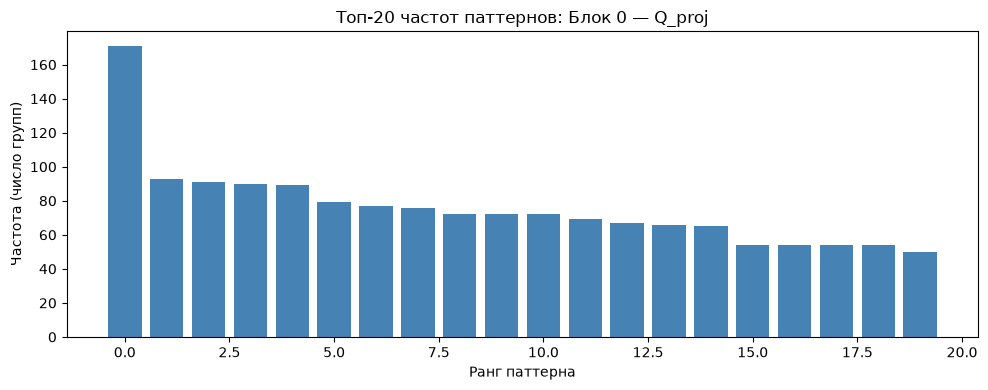

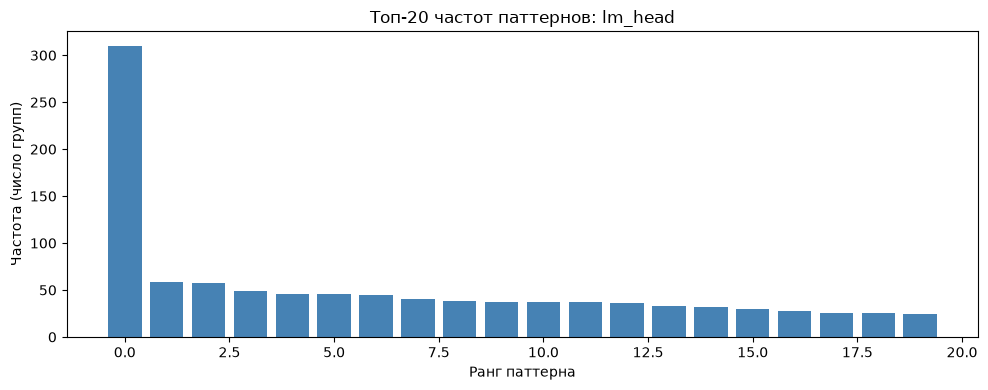

In [18]:
def plot_pattern_frequency(info, layer_name, top_n=20):
    counts = np.sort(info['counts'])[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(counts)), counts, color='steelblue')
    ax.set_title(f'Топ-{len(counts)} частот паттернов: {layer_name}')
    ax.set_xlabel('Ранг паттерна'); ax.set_ylabel('Частота (число групп)')
    plt.tight_layout(); plt.show()

plot_pattern_frequency(res_q, 'Блок 0 — Q_proj')
plot_pattern_frequency(res_lm, 'lm_head')

📐 Геометрический предел 3D -> 5D (уровней: 3):
Случайные точки покрывают: 113 из 243 паттернов (46.50%)
📊 Анализ слоя: Блок 0 — Q_proj (group_size: 5, уровней: 3)
Всего групп весов: 3328
Использовано уникальных паттернов: 123 из 243 (50.62%)
Топ-3 самых частых паттерна:
  [0, 0, 0, 0, 0] -> 171 раз
  [1, -1, 1, -1, -1] -> 93 раз
  [-1, 1, -1, 1, 0] -> 91 раз
--------------------------------------------------


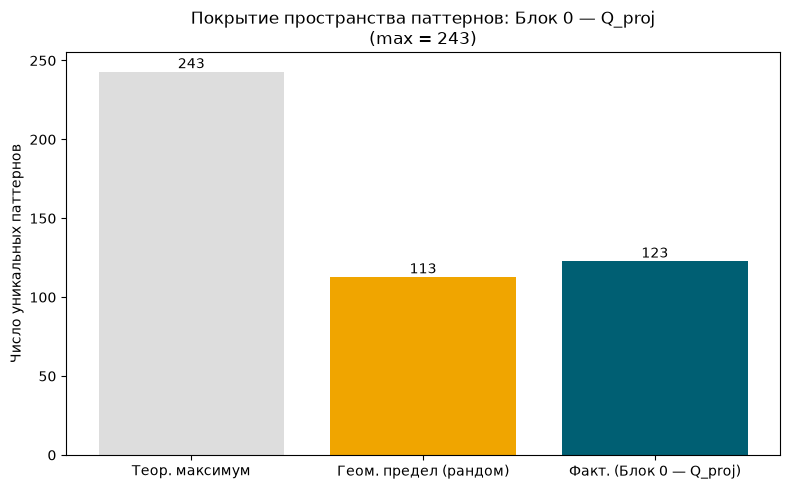

In [19]:
def plot_coverage(layer, layer_name):
    th = check_theoretical_limit(layer)
    res = analyze_combinations(layer, layer_name)
    labels = ['Теор. максимум', 'Геом. предел (рандом)', f'Факт. ({layer_name})']
    values = [th['max_possible'], th['n_reachable'], res['n_used']]
    colors = ['#dddddd', '#f0a500', '#005f73']
    mp = th['max_possible']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=colors)
    ax.set_ylabel('Число уникальных паттернов')
    ax.set_title(f'Покрытие пространства паттернов: {layer_name}\n(max = {mp})')
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout(); plt.show()

plot_coverage(model.blocks[0].attn.q_proj, 'Блок 0 — Q_proj')

## Замечания

- `reproduce_layer_patterns` точно повторяет нормировку forward-прохода `BaseHypercubeLinear`
  (центрирование по строке, глобальный масштаб, затем `layer.quantize`).
- `check_theoretical_limit` использует независимое центрирование каждой группы — это отвечает
  на вопрос «сколько паттернов вообще достижимо из 3D через данную матрицу проекции».
- Чтобы протестировать бинарный или 2-битный режим, переключите `LayerClass` в ячейке обучения:
  функции анализа определят число уровней автоматически.